In [1]:
from weather_engine.database import engine
import pandas as pd
import xgboost as xgb
from weather_engine.llocv import load_fold, temporal_split_fold


FEATURES = ['rain', 'ws', 'td', 'rh', 'tdmax', 'tdmin', 'u_vec', 'v_vec']
TEST_STATION_ID = 16  # Afula — held out entirely, not used in training

station_neighbors: pd.DataFrame = pd.read_sql("SELECT * FROM station_neighbors", engine)
test_station_row = station_neighbors[station_neighbors["station_id"] == TEST_STATION_ID].iloc[0]

station_neighbors = station_neighbors[
    (station_neighbors["station_id"] != TEST_STATION_ID) &
    (station_neighbors["neighbor_1_id"] != TEST_STATION_ID) &
    (station_neighbors["neighbor_2_id"] != TEST_STATION_ID) &
    (station_neighbors["neighbor_3_id"] != TEST_STATION_ID)
].reset_index(drop=True)

In [12]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from weather_engine.utils import encode_time_features
import numpy as np

all_X = []
all_y = []

all_data = pd.read_sql("SELECT * FROM clean_station_data", engine)
all_data['timestamp'] = pd.to_datetime(all_data['timestamp'])

all_data = all_data.set_index('timestamp').sort_index()
station_frames = {sid: grp.drop(columns='station_id') 
                  for sid, grp in all_data.groupby('station_id')}

X_test, y_test = load_fold(
    TEST_STATION_ID,
    int(test_station_row["neighbor_1_id"]),
    int(test_station_row["neighbor_2_id"]), 
    int(test_station_row["neighbor_3_id"]),
    station_frames=station_frames
)

X_test = encode_time_features(X_test)

for _, row in station_neighbors.iterrows():
    X, y = load_fold(
        int(row["station_id"]),
        int(row["neighbor_1_id"]),
        int(row["neighbor_2_id"]), 
        int(row["neighbor_3_id"]),
        station_frames=station_frames
    )
    
    all_X.append(X)
    all_y.append(y)
print("All folds loaded.")


all_X = pd.concat(all_X).sort_index()
all_y = pd.concat(all_y).sort_index()

all_X = encode_time_features(all_X)  # Adds month and day encodings

X_train, X_val, y_train, y_val = temporal_split_fold(all_X, all_y)

TERRAIN_FEATURES = ['rain', 'ws', 'rh']
TERRAIN_COLS = [c for c in X_train.columns if any(c.startswith(p) for p in ['tpi_', 'roughness_'])]

models = {}
errors = {}

for feature in FEATURES:
    print(f"[{FEATURES.index(feature) + 1}/{len(FEATURES)}] Training RFSI for '{feature}'...", end=' ')
    drop_cols = [] if feature in TERRAIN_FEATURES else TERRAIN_COLS
    _x_train = X_train.drop(columns=drop_cols)
    _x_val = X_val.drop(columns=drop_cols)
    
    if feature == 'rain':
        model = xgb.XGBRegressor(n_jobs=-1, objective='reg:tweedie', tweedie_variance_power=1.5)
    else:
        model = xgb.XGBRegressor(n_jobs=-1, objective='reg:squarederror')
    
    model.fit(_x_train, y_train[feature])
    preds = model.predict(_x_val)
    mae = mean_absolute_error(y_val[feature], preds)
    rmse = root_mean_squared_error(y_val[feature], preds)
    errors[feature] = {'mae': mae, 'rmse': rmse}
    models[feature] = model
    print(f"MAE={mae:.4f}  RMSE={rmse:.4f}")


All folds loaded.
[1/8] Training RFSI for 'rain'... MAE=0.0316  RMSE=0.3416
[2/8] Training RFSI for 'ws'... MAE=0.6837  RMSE=0.9464
[3/8] Training RFSI for 'td'... MAE=0.7954  RMSE=1.0989
[4/8] Training RFSI for 'rh'... MAE=4.2343  RMSE=6.1689
[5/8] Training RFSI for 'tdmax'... MAE=0.8215  RMSE=1.1308
[6/8] Training RFSI for 'tdmin'... MAE=0.8157  RMSE=1.1244
[7/8] Training RFSI for 'u_vec'... MAE=0.7889  RMSE=1.1201
[8/8] Training RFSI for 'v_vec'... MAE=0.7309  RMSE=1.0198


In [13]:
print(f"X training/validation columns: {all_X.columns}\n X testing columns: {X_test.columns}")

X training/validation columns: Index(['rain_n1', 'ws_n1', 'td_n1', 'rh_n1', 'tdmax_n1', 'tdmin_n1',
       'u_vec_n1', 'v_vec_n1', 'rain_n2', 'ws_n2', 'td_n2', 'rh_n2',
       'tdmax_n2', 'tdmin_n2', 'u_vec_n2', 'v_vec_n2', 'rain_n3', 'ws_n3',
       'td_n3', 'rh_n3', 'tdmax_n3', 'tdmin_n3', 'u_vec_n3', 'v_vec_n3',
       'elevation_target', 'tpi_local_target', 'tpi_regional_target',
       'roughness_local_target', 'roughness_regional_target',
       'dist_to_coast_target', 'elevation_n1', 'tpi_local_n1',
       'tpi_regional_n1', 'roughness_local_n1', 'roughness_regional_n1',
       'dist_to_coast_n1', 'elevation_n2', 'tpi_local_n2', 'tpi_regional_n2',
       'roughness_local_n2', 'roughness_regional_n2', 'dist_to_coast_n2',
       'elevation_n3', 'tpi_local_n3', 'tpi_regional_n3', 'roughness_local_n3',
       'roughness_regional_n3', 'dist_to_coast_n3', 'dist_n1', 'dist_n2',
       'dist_n3', 'month_sin', 'month_cos', 'day_sin', 'day_cos'],
      dtype='object')
 X testing columns: 

Checking performance on rainy days only

In [14]:
rain_preds = models['rain'].predict(X_val)
rain_mask = y_val['rain'] >= 0.1

y_rain_true = y_val['rain'][rain_mask]
y_rain_pred = rain_preds[rain_mask]

mae_rain = mean_absolute_error(y_rain_true, y_rain_pred)
rmse_rain = root_mean_squared_error(y_rain_true, y_rain_pred)

print(f"Rain-only (>= 0.1mm) — n={rain_mask.sum()}")
print(f"MAE={mae_rain:.4f}  RMSE={rmse_rain:.4f}")


Rain-only (>= 0.1mm) — n=17571
MAE=0.8564  RMSE=1.9313


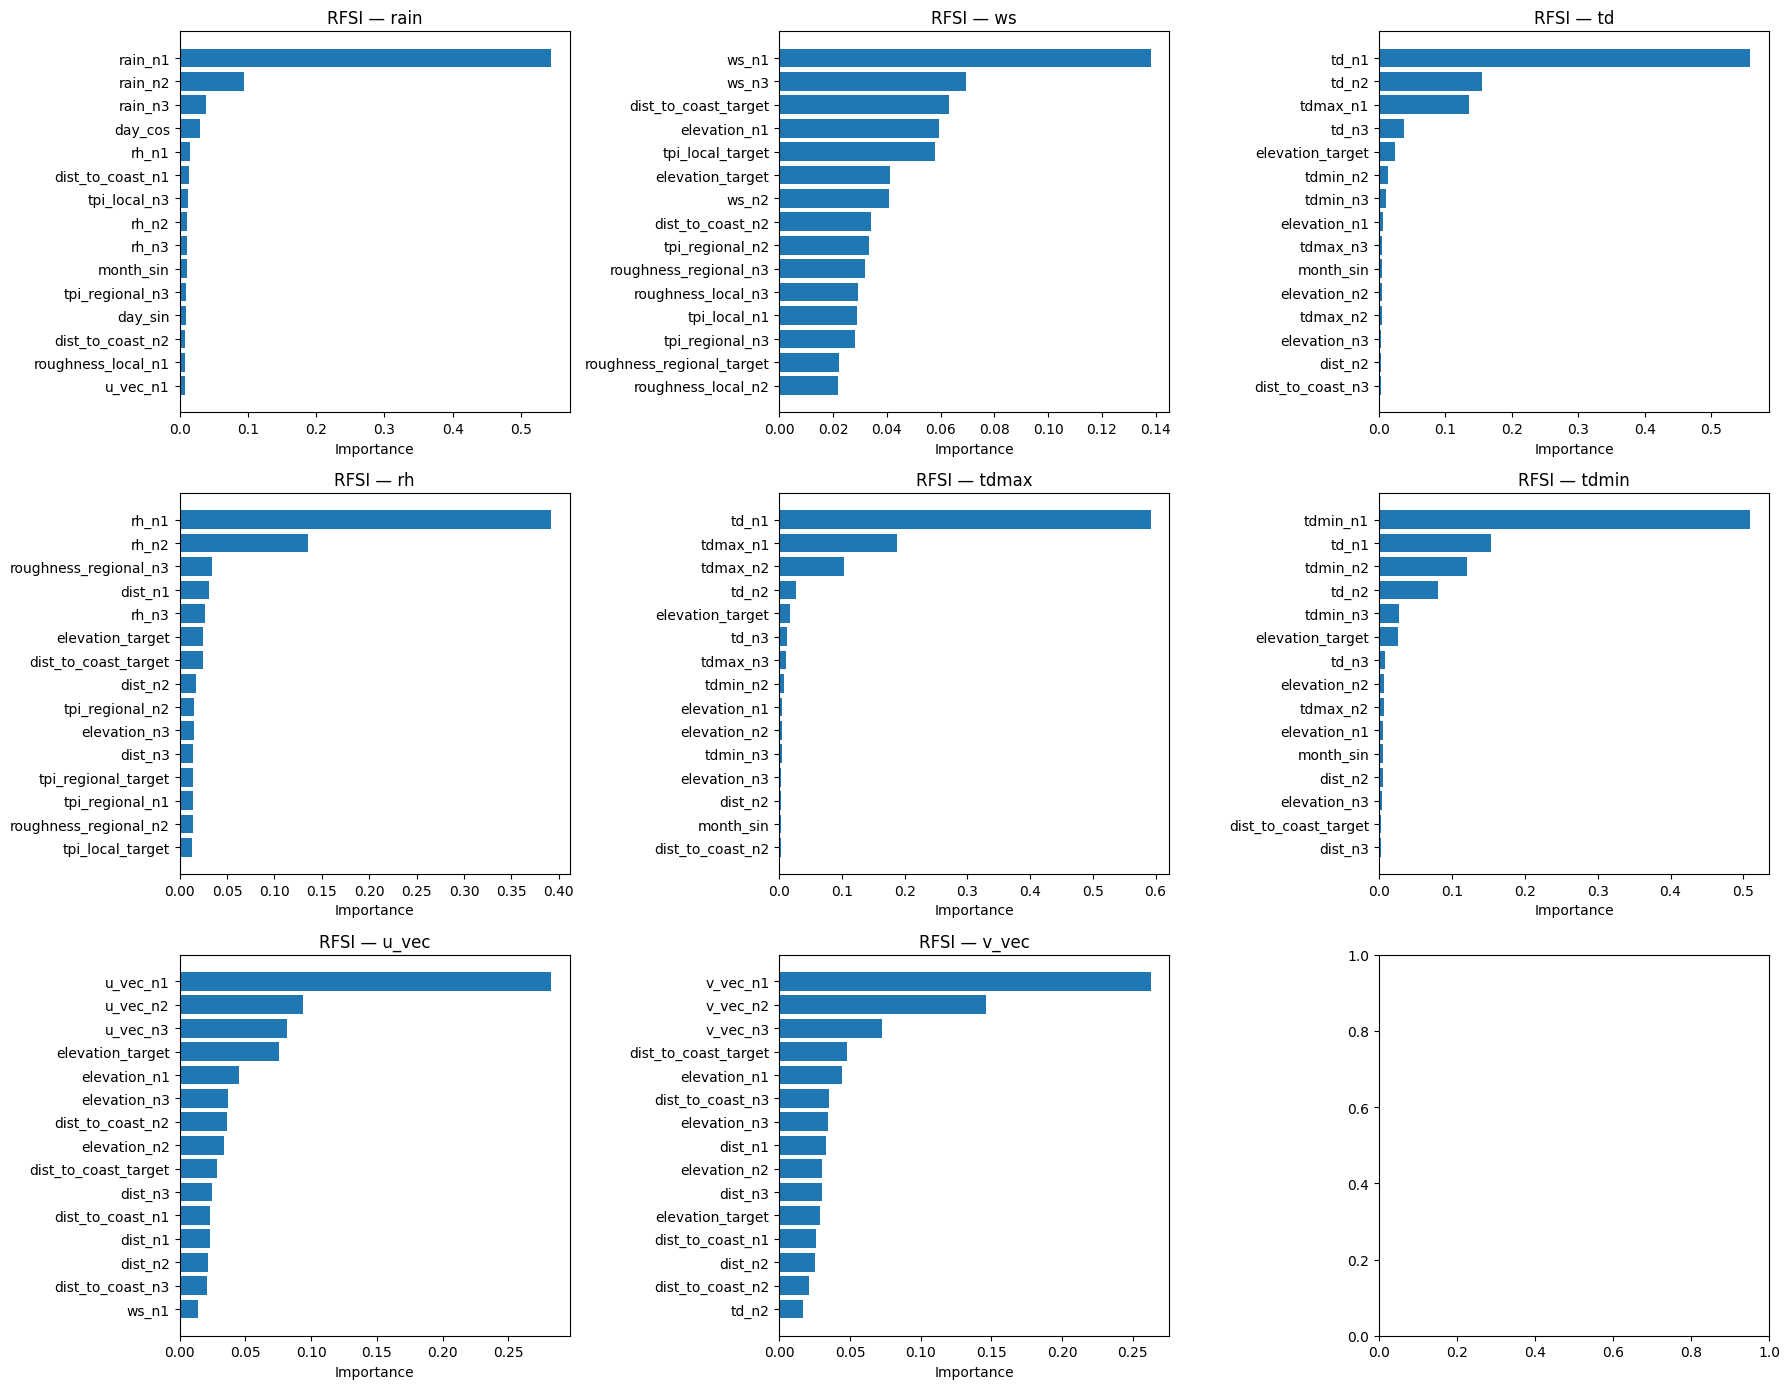

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, (feature, model) in enumerate(models.items()):
    importances = model.feature_importances_
    feature_names = np.array(model.get_booster().feature_names)
    sorted_idx = importances.argsort()[::-1][:15]  # top 15

    axes[i].barh(feature_names[sorted_idx][::-1], importances[sorted_idx][::-1])
    axes[i].set_title(f'RFSI — {feature}')
    axes[i].set_xlabel('Importance')

plt.tight_layout()
plt.show()


In [16]:
n1_dists = station_neighbors["neighbor_1_distance"].mean()
n2_dists = station_neighbors["neighbor_2_distance"].mean()
n3_dists = station_neighbors["neighbor_3_distance"].mean()

print(f"Mean of distance to neighbor 1: {n1_dists}\nMean of distance to neighbor 2: {n2_dists}\nMean of distance to neighbor 3: {n3_dists}")

Mean of distance to neighbor 1: 13.25037046883842
Mean of distance to neighbor 2: 19.61130247099956
Mean of distance to neighbor 3: 28.68110844356596


Now we run baseline interpolation using IDW to compare our XGBoost spatial interpolator to

In [17]:

weights = (1/X_test['dist_n1'] + 1/X_test['dist_n2'] + 1/X_test['dist_n3'])
idw_preds = {}
for feature in FEATURES:
    idw_pred = (X_test[f'{feature}_n1']/X_test['dist_n1'] + X_test[f'{feature}_n2']/X_test['dist_n2'] + X_test[f'{feature}_n3']/X_test['dist_n3']) / weights
    idw_preds[feature] = idw_pred.values

Those results explain why neighbor 3 in the feature importances is mostly the lowest in terms of impact, since the farther away a data source is the less relevant to our target weather.

rain
rain: MAE=0.0432  RMSE=0.3255  RMSE(rain-only)=1.4819
Scaled rain: MAE Scaled=0.8034  RMSE Scaled=6.0542  RMSE(rain-only) Scaled=1.2253

IDW rain: MAE=0.0479  RMSE=0.3596  RMSE(rain-only)=1.5624
IDW Scaled rain: MAE Scaled=0.8912  RMSE Scaled=6.6888  RMSE(rain-only) Scaled=1.2919

ws
ws: MAE=0.7924  RMSE=1.0042
Scaled ws: MAE Scaled=0.3472  RMSE Scaled=0.4400

IDW ws: MAE=1.1119  RMSE=1.2957
IDW Scaled ws: MAE Scaled=0.4873  RMSE Scaled=0.5678

td
td: MAE=1.2967  RMSE=1.6628
Scaled td: MAE Scaled=0.0631  RMSE Scaled=0.0809

IDW td: MAE=1.0182  RMSE=1.4104
IDW Scaled td: MAE Scaled=0.0496  RMSE Scaled=0.0687

rh
rh: MAE=4.2538  RMSE=5.6431
Scaled rh: MAE Scaled=0.0620  RMSE Scaled=0.0822

IDW rh: MAE=4.2575  RMSE=5.8825
IDW Scaled rh: MAE Scaled=0.0620  RMSE Scaled=0.0857

tdmax
tdmax: MAE=1.1890  RMSE=1.6070
Scaled tdmax: MAE Scaled=0.0559  RMSE Scaled=0.0756

IDW tdmax: MAE=0.9822  RMSE=1.3671
IDW Scaled tdmax: MAE Scaled=0.0462  RMSE Scaled=0.0643

tdmin
tdmin: MAE=1.3368  RMSE=

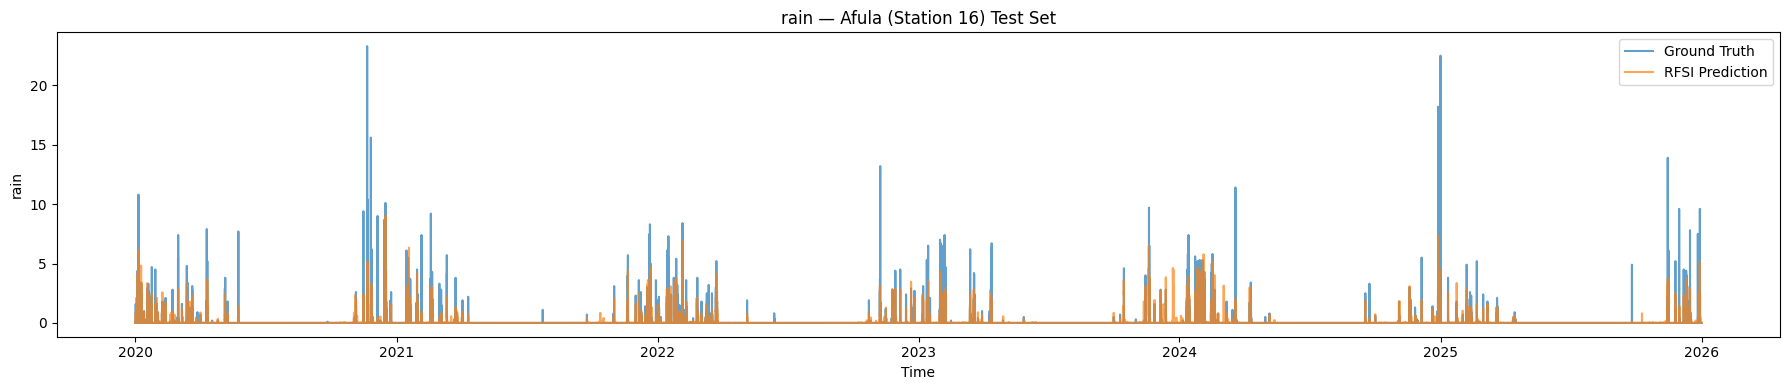

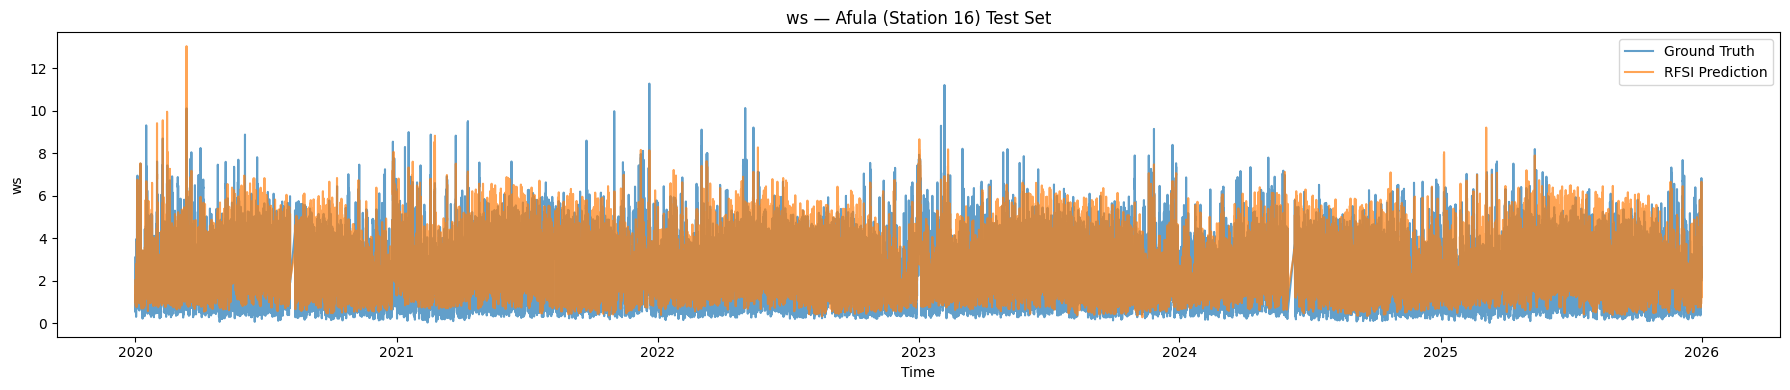

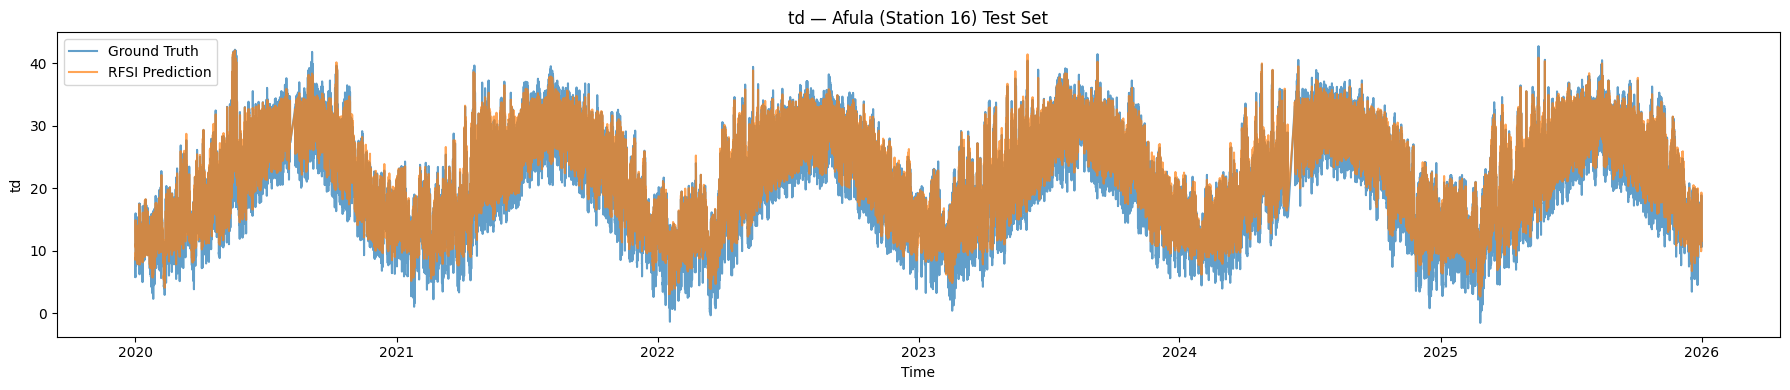

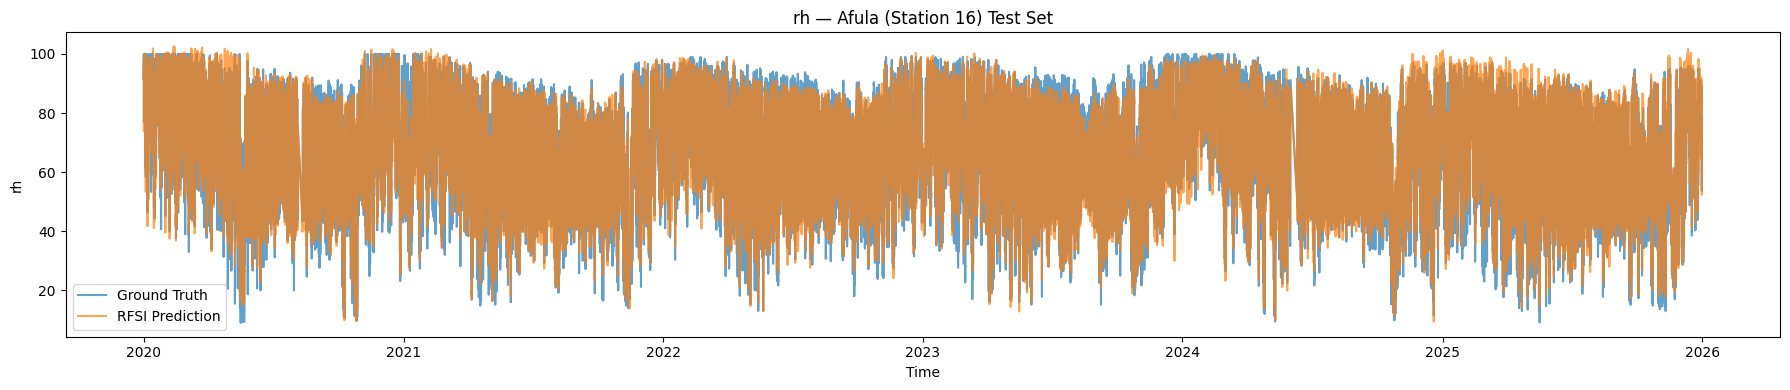

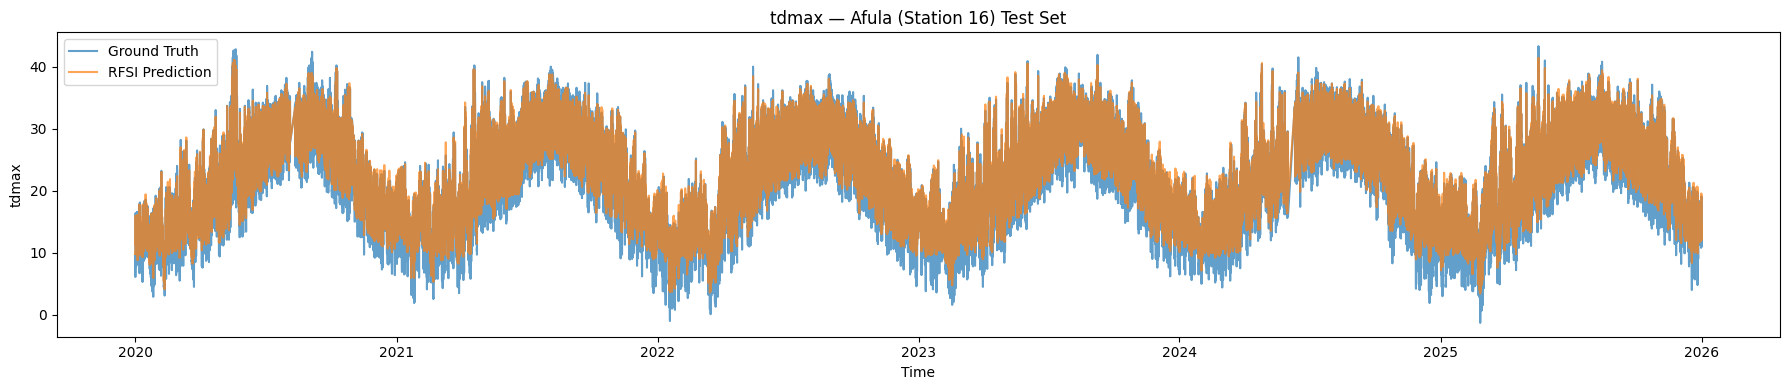

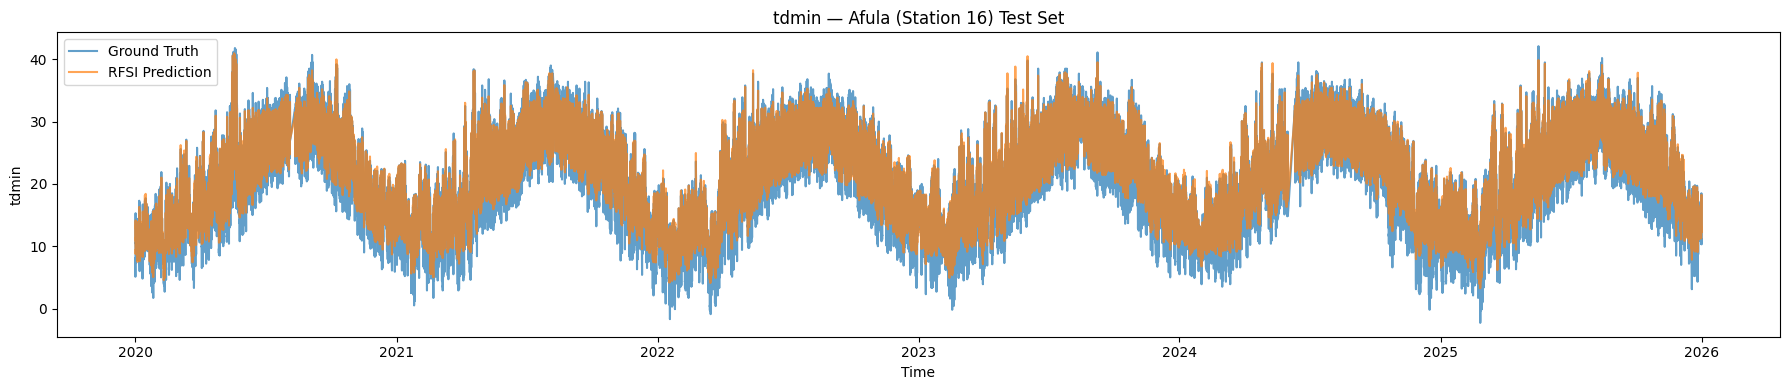

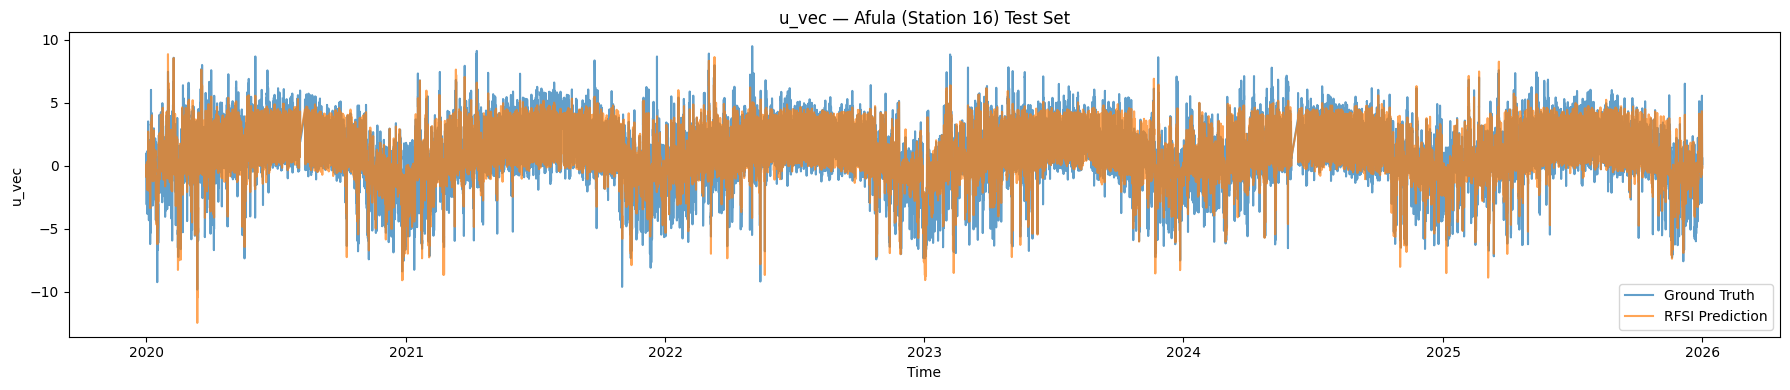

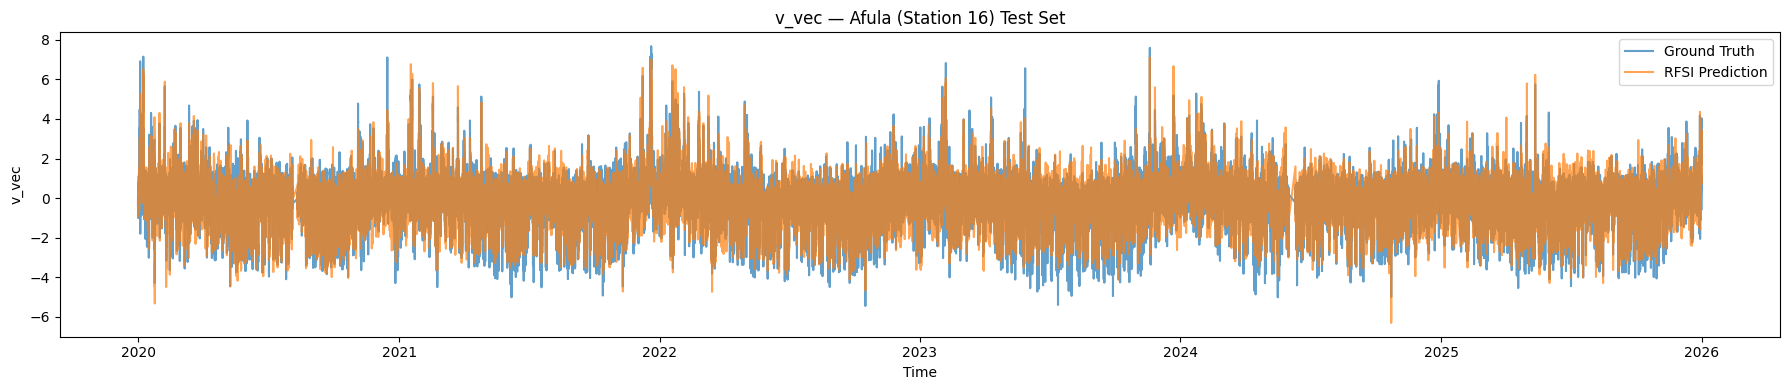

In [19]:
test_preds = {}

for feature, model in models.items():
    drop_cols = [] if feature in TERRAIN_FEATURES else TERRAIN_COLS
    _x_test = X_test.drop(columns=drop_cols)
    preds = model.predict(_x_test)
    mae = mean_absolute_error(y_test[feature], preds)
    idw_maw = mean_absolute_error(y_test[feature], idw_preds[feature])
    rmse = root_mean_squared_error(y_test[feature], preds)
    idw_rmse = root_mean_squared_error(y_test[feature], idw_preds[feature])
    test_preds[feature] = preds
    
    scale = np.mean(np.abs(y_test[feature]))
    
    mae_scaled = mae / scale
    rmse_scaled = rmse / scale
    idw_mae_scaled = idw_maw / scale
    idw_rmse_scaled = idw_rmse / scale
    
    print("="*40)
    print(feature)
    print("="*40)
    if feature == 'rain':
        rain_mask = y_test[feature] >= 0.1
        rmse_rain = root_mean_squared_error(y_test[feature][rain_mask], preds[rain_mask])
        idw_rmse_rain = root_mean_squared_error(y_test[feature][rain_mask], idw_preds[feature][rain_mask])
        rmse_rain_scaled = rmse_rain / np.mean(y_test[feature][rain_mask])
        idw_rmse_rain_scaled = idw_rmse_rain / np.mean(y_test[feature][rain_mask])
        print(f"{feature}: MAE={mae:.4f}  RMSE={rmse:.4f}  RMSE(rain-only)={rmse_rain:.4f}")
        print(f"Scaled {feature}: MAE Scaled={mae_scaled:.4f}  RMSE Scaled={rmse_scaled:.4f}  RMSE(rain-only) Scaled={rmse_rain_scaled:.4f}\n") 
        print(f"IDW {feature}: MAE={idw_maw:.4f}  RMSE={idw_rmse:.4f}  RMSE(rain-only)={idw_rmse_rain:.4f}")
        print(f"IDW Scaled {feature}: MAE Scaled={idw_mae_scaled:.4f}  RMSE Scaled={idw_rmse_scaled:.4f}  RMSE(rain-only) Scaled={idw_rmse_rain_scaled:.4f}\n")
    else:
        print(f"{feature}: MAE={mae:.4f}  RMSE={rmse:.4f}")
        print(f"Scaled {feature}: MAE Scaled={mae_scaled:.4f}  RMSE Scaled={rmse_scaled:.4f}\n")
        print(f"IDW {feature}: MAE={idw_maw:.4f}  RMSE={idw_rmse:.4f}")
        print(f"IDW Scaled {feature}: MAE Scaled={idw_mae_scaled:.4f}  RMSE Scaled={idw_rmse_scaled:.4f}\n")


for feature, preds in test_preds.items():
    plt.figure(figsize=(18, 4))
    plt.plot(y_test.index, y_test[feature], label='Ground Truth', alpha=0.7)
    plt.plot(y_test.index, preds, label='RFSI Prediction', alpha=0.7)
    plt.title(f'{feature} — Afula (Station 16) Test Set')
    plt.xlabel('Time')
    plt.ylabel(feature)
    plt.legend()
    plt.tight_layout()
    plt.show()


Lets display errors with coloring and display storm bias for rain

In [20]:
rows = []
for feature in FEATURES:
    y_true = y_test[feature].values
    preds = test_preds[feature]
    mae = mean_absolute_error(y_true, preds)
    rmse = root_mean_squared_error(y_true, preds)

    if feature == 'rain':
        mask = y_true >= 0.1
        storm_bias = float(np.mean(preds[mask] - y_true[mask])) if mask.sum() > 0 else np.nan
    else:
        storm_bias = np.nan

    rows.append({'Feature': feature, 'MAE': mae, 'RMSE': rmse, 'Storm Bias': storm_bias})

df_metrics = pd.DataFrame(rows).set_index('Feature')
abs_max_bias = df_metrics['Storm Bias'].abs().max()

display(
    df_metrics.style
    .format({'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'Storm Bias': '{:.4f}'}, na_rep='—')
    .background_gradient(cmap='coolwarm', subset=['MAE', 'RMSE'])
    .background_gradient(cmap='RdYlGn_r', subset=['Storm Bias'], vmin=-abs_max_bias, vmax=abs_max_bias)
)


,MAE,RMSE,Storm Bias
Feature,,,
rain,0.0432,0.3255,-0.3050
ws,0.7924,1.0042,—
td,1.2967,1.6628,—
rh,4.2538,5.6431,—
tdmax,1.1890,1.6070,—
tdmin,1.3368,1.8160,—
u_vec,0.8624,1.1308,—
v_vec,0.7278,0.9352,—


Here we check for a systematic bias in wind vector interpolation.

The goal is as close to 0 as possible since that would mean our model isn't pointing in some direction due to a systematic error.

In [21]:
import numpy as np

for feature in ['u_vec', 'v_vec']:
    err = test_preds[feature] - y_test[feature].values
    print(f"{feature}: mean error = {err.mean():.4f}, std = {err.std():.4f}")

# Direction bias: compare mean predicted vs true direction
u_true, v_true = y_test['u_vec'].values, y_test['v_vec'].values
u_pred, v_pred = test_preds['u_vec'], test_preds['v_vec']

true_dir = np.degrees(np.arctan2(v_true, u_true))
pred_dir = np.degrees(np.arctan2(v_pred, u_pred))

angle_diff = pred_dir - true_dir
# Wrap to [-180, 180]
angle_diff = (angle_diff + 180) % 360 - 180

print(f"Mean direction error: {angle_diff.mean():.2f}°, std: {angle_diff.std():.2f}°")


u_vec: mean error = -0.0820, std = 1.1278
v_vec: mean error = -0.1105, std = 0.9286
Mean direction error: -13.19°, std: 67.63°


We see the v_vec has a very small bias of -0.1 degrees which wont affect us much.

u_vec has a higher bias of 0.46 from 0.76 degrees before adding distance to coast, so its clear it was able to reduce the eastward wind bias by 39%.

now we save the models for production/pipeline testing

In [24]:
from pathlib import Path
from weather_engine.utils import get_project_root

root_path = get_project_root()
spatial_path = root_path / "models" / "spatial_interpolation"
spatial_path.mkdir(parents=True, exist_ok=True)

for feature, model in models.items():
    save_path = spatial_path / f"xgb_{feature}.json"
    model.get_booster().save_model(save_path)
    